# Micro Proyecto 3 - Fine-tuning Llama-3.2-1B en RACE (Multiple Choice QA)

**Estrategia para superar 0.75 de accuracy fine-tuned:**
- Prompt estructurado: articulo + pregunta + opciones etiquetadas
- Evaluacion por log-probabilidad normalizada del token de respuesta (A/B/C/D)
- LoRA con `r=16`, `lora_alpha=32`, aplicado a Q/K/V/O + capas MLP
- Scheduler coseno con warmup, gradient accumulation y 3 epocas
- Label masking correcto: solo el token de respuesta contribuye a la perdida


## 1. Instalacion de dependencias


In [1]:
!pip install -q transformers==4.44.0 peft==0.12.0 datasets==2.21.0 accelerate==0.34.2 tqdm

## 2. Imports y configuracion global


In [2]:
import os
import math
import torch
import numpy as np
from tqdm import tqdm
from datasets import load_dataset
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    BitsAndBytesConfig,
    get_cosine_schedule_with_warmup,
)
from peft import LoraConfig, get_peft_model, TaskType, PeftModel, prepare_model_for_kbit_training

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Usando dispositivo: {DEVICE}")
if DEVICE == "cuda":
    print(f"  GPU: {torch.cuda.get_device_name(0)}")
    print(f"  VRAM total: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

MODEL_NAME      = "meta-llama/Llama-3.2-1B"
MAX_ARTICLE_LEN = 800
MAX_SEQ_LEN     = 256
CHECKPOINT_PATH = "./llama_race_lora.pt"

os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
print("Imports y configuracion listos")


Usando dispositivo: cuda
  GPU: Tesla T4
  VRAM total: 15.6 GB
Imports y configuracion listos


## 3. Carga y filtrado del dataset RACE


In [3]:
print("Cargando dataset RACE...")
race_train = load_dataset("race", "all", split="train")
race_val   = load_dataset("race", "all", split="validation")
race_test  = load_dataset("race", "all", split="test")

def filter_short(example):
    return len(example["article"]) < MAX_ARTICLE_LEN

train_ds = race_train.filter(filter_short)
val_ds   = race_val.filter(filter_short)
test_ds  = race_test.filter(filter_short)

print(f"Train  : {len(train_ds):>6,} ejemplos")
print(f"Val    : {len(val_ds):>6,} ejemplos")
print(f"Test   : {len(test_ds):>6,} ejemplos")

sample = train_ds[0]
print("\n--- Ejemplo ---")
print(f"Articulo ({len(sample['article'])} chars): {sample['article'][:200]}...")
print(f"Pregunta : {sample['question']}")
print(f"Opciones : {sample['options']}")
print(f"Respuesta: {sample['answer']}")


Cargando dataset RACE...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Train  :  8,930 ejemplos
Val    :    514 ejemplos
Test   :    480 ejemplos

--- Ejemplo ---
Articulo (790 chars): The air hostess   was in a small kitchen at the back of the plane, preparing the plates for lunch, when a little old lady came and spoke to her, "Could you please tell me," she asked, "where is the la...
Pregunta : The story happened  _  .
Opciones : ['in the evening', 'in the afternoon', 'in the morning', 'at midnight']
Respuesta: C


## 4. Template de prompt

El prompt incluye el articulo, la pregunta y las 4 opciones etiquetadas.
Termina con `Answer:` para que el modelo aprenda a generar solo la letra correcta.
Durante la evaluacion se mide `log P(letra | contexto)` normalizado por numero de tokens.


In [4]:
def build_context(article, question, options):
    """Construye el prompt SIN la respuesta (usado en evaluacion y como prefijo en training)."""
    letters = ["A", "B", "C", "D"]
    opts_str = "\n".join(f"{l}. {o}" for l, o in zip(letters, options))
    return (
        f"Read the article and choose the best answer.\n\n"
        f"Article: {article}\n\n"
        f"Question: {question}\n\n"
        f"{opts_str}\n\n"
        f"Answer:"
    )

def build_full_prompt(article, question, options, answer):
    """Contexto + letra de respuesta (para entrenamiento)."""
    return build_context(article, question, options) + f" {answer}"

# Prueba rapida
ctx = build_context(sample["article"], sample["question"], sample["options"])
print("--- Contexto (primeros 400 chars) ---")
print(ctx[:400])
print("\n--- Final del prompt completo ---")
full = build_full_prompt(sample["article"], sample["question"], sample["options"], sample["answer"])
print(full[-60:])


--- Contexto (primeros 400 chars) ---
Read the article and choose the best answer.

Article: The air hostess   was in a small kitchen at the back of the plane, preparing the plates for lunch, when a little old lady came and spoke to her, "Could you please tell me," she asked, "where is the ladies' lavatory   in the plane?"
"Yes, madam," said the air hostess and smiled. "It is right at the other end of the plane---at the front."
The li

--- Final del prompt completo ---
in the afternoon
C. in the morning
D. at midnight

Answer: C


## 5. Tokenizador


In [5]:
from huggingface_hub import login
from google.colab import userdata

HF_TOKEN = ''
login(token=HF_TOKEN)

print('Iniciado sesión en Hugging Face.')

Iniciado sesión en Hugging Face.


In [6]:
print(f"Cargando tokenizador de {MODEL_NAME}...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)

# Llama no tiene pad_token por defecto
tokenizer.pad_token    = tokenizer.eos_token
tokenizer.padding_side = "right"

# Verificar ids de las letras de respuesta
for letter in ["A", "B", "C", "D"]:
    ids = tokenizer.encode(f" {letter}", add_special_tokens=False)
    print(f"  ' {letter}' -> token ids: {ids}")

print("Tokenizador listo")


Cargando tokenizador de meta-llama/Llama-3.2-1B...
  ' A' -> token ids: [362]
  ' B' -> token ids: [426]
  ' C' -> token ids: [356]
  ' D' -> token ids: [423]
Tokenizador listo


## 6. Dataset de PyTorch con label masking


In [7]:
class RACEDataset(Dataset):
    """
    Tokeniza el prompt completo y enmascara con -100 todos los tokens
    excepto los de la respuesta (letra correcta).
    """
    def __init__(self, hf_dataset, tokenizer, max_length=MAX_SEQ_LEN):
        self.tokenizer  = tokenizer
        self.max_length = max_length
        self.examples   = []

        for ex in tqdm(hf_dataset, desc="Tokenizando"):
            full_text = build_full_prompt(
                ex["article"], ex["question"], ex["options"], ex["answer"]
            )
            ctx_text = build_context(
                ex["article"], ex["question"], ex["options"]
            )

            full_enc = tokenizer(
                full_text,
                max_length=max_length,
                truncation=True,
                padding="max_length",
                return_tensors="pt",
            )
            ctx_ids = tokenizer(
                ctx_text,
                add_special_tokens=False,
                truncation=True,
                max_length=max_length - 2,
            )["input_ids"]
            ctx_len = len(ctx_ids)

            input_ids      = full_enc["input_ids"].squeeze()
            attention_mask = full_enc["attention_mask"].squeeze()

            # Labels: -100 en todo menos en la letra de respuesta
            labels   = torch.full_like(input_ids, -100)
            real_len = attention_mask.sum().item()
            ans_start = ctx_len
            ans_end   = int(real_len) - 1
            if ans_start < real_len:
                labels[ans_start:ans_end + 1] = input_ids[ans_start:ans_end + 1]

            self.examples.append({
                "input_ids":      input_ids,
                "attention_mask": attention_mask,
                "labels":         labels,
            })

    def __len__(self):         return len(self.examples)
    def __getitem__(self, idx): return self.examples[idx]


print("Clase RACEDataset definida")


Clase RACEDataset definida


In [8]:
train_dataset = RACEDataset(train_ds, tokenizer)
val_dataset   = RACEDataset(val_ds,   tokenizer)

print(f"Train: {len(train_dataset)} muestras")
print(f"Val  : {len(val_dataset)} muestras")

item = train_dataset[0]
active = (item["labels"] != -100).sum().item()
print(f"Tokens con label activo en muestra 0: {active} (deben ser ~1-2)")


Tokenizando: 100%|██████████| 514/514 [00:01<00:00, 409.41it/s]

Train: 8930 muestras
Val  : 514 muestras
Tokens con label activo en muestra 0: 2 (deben ser ~1-2)


## 7. Funcion de evaluacion por log-probabilidad

Para cada ejemplo calcula `log P(letra | contexto)` normalizado y elige el argmax:

```
score(s) = sum_i log P(s_i | s_{<i}, contexto) / n_tokens(s)
Respuesta = argmax_s score(s)
```


In [9]:
@torch.no_grad()
def evaluate_model(model, dataset_hf, tokenizer, device, max_length=MAX_SEQ_LEN):
    model.eval()
    letters = ["A", "B", "C", "D"]
    correct = 0
    total   = 0

    for ex in tqdm(dataset_hf, desc="Evaluando"):
        ctx_text = build_context(ex["article"], ex["question"], ex["options"])
        true_ans = ex["answer"]
        scores   = []

        for letter in letters:
            full_text = ctx_text + f" {letter}"
            enc = tokenizer(
                full_text, return_tensors="pt",
                max_length=max_length, truncation=True
            ).to(device)
            ctx_len = tokenizer(
                ctx_text, return_tensors="pt",
                max_length=max_length, truncation=True,
                add_special_tokens=False
            )["input_ids"].shape[1]

            logits    = model(**enc).logits
            log_probs = torch.nn.functional.log_softmax(logits, dim=-1)
            total_len = enc["input_ids"].shape[1]

            lp = 0.0
            n  = 0
            for pos in range(ctx_len, total_len):
                tok  = enc["input_ids"][0, pos].item()
                lp  += log_probs[0, pos - 1, tok].item()
                n   += 1
            scores.append(lp / max(n, 1))

        pred = letters[int(np.argmax(scores))]
        if pred == true_ans:
            correct += 1
        total += 1

    acc = correct / total if total > 0 else 0.0
    print(f"Accuracy: {acc:.4f}  ({correct}/{total})")
    return acc


print("Funcion de evaluacion definida")


Funcion de evaluacion definida


## 8. Carga del modelo base y evaluacion inicial


In [10]:
print(f"Cargando {MODEL_NAME} en float16...")

base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16,
    device_map="auto",
)
print(f"VRAM usada: {torch.cuda.memory_allocated()/1e9:.2f} GB")

Cargando meta-llama/Llama-3.2-1B en float16...
VRAM usada: 2.47 GB


In [11]:
print("=" * 50)
print("Evaluacion del modelo BASE en test set")
print("=" * 50)
base_accuracy = evaluate_model(base_model, test_ds, tokenizer, DEVICE)
print(f"\nBase Accuracy: {base_accuracy:.4f}")


Evaluacion del modelo BASE en test set


Evaluando: 100%|██████████| 480/480 [01:22<00:00,  5.83it/s]

Accuracy: 0.4229  (203/480)

Base Accuracy: 0.4229


## 9. Configuracion LoRA

- `r=16`, `lora_alpha=32` en attencion (Q/K/V/O) y capas MLP (gate/up/down).
- Esto duplica la capacidad de adaptacion frente a configuraciones minimas (`r=4/8`).


In [12]:
torch.cuda.empty_cache()

lora_config = LoraConfig(
    task_type      = TaskType.CAUSAL_LM,
    r              = 16,
    lora_alpha     = 32,
    lora_dropout   = 0.05,
    bias           = "none",
    target_modules = ["q_proj", "k_proj", "v_proj", "o_proj",
                      "gate_proj", "up_proj", "down_proj"],
)

model = get_peft_model(base_model, lora_config)
model.enable_input_require_grads()
model.gradient_checkpointing_enable()
model.config.use_cache = False

model.print_trainable_parameters()
print(f"VRAM tras LoRA: {torch.cuda.memory_allocated()/1e9:.2f} GB")

trainable params: 11,272,192 || all params: 1,247,086,592 || trainable%: 0.9039
VRAM tras LoRA: 2.53 GB


## 10. DataLoaders y entrenamiento


In [13]:
EPOCHS             = 3
BATCH_SIZE         = 1
GRAD_ACCUM_STEPS   = 16
LR                 = 2e-4
WARMUP_RATIO       = 0.10
WEIGHT_DECAY       = 0.01
MAX_GRAD_NORM      = 1.0
EVAL_EVERY_N_STEPS = 200

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=2, pin_memory=True
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2
)

total_steps  = (len(train_loader) * EPOCHS) // GRAD_ACCUM_STEPS
warmup_steps = int(total_steps * WARMUP_RATIO)
print(f"Pasos totales : {total_steps}")
print(f"Pasos warmup  : {warmup_steps}")
print(f"Batch efectivo: {BATCH_SIZE * GRAD_ACCUM_STEPS}")


Pasos totales : 1674
Pasos warmup  : 167
Batch efectivo: 16


In [14]:
optimizer = AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR, weight_decay=WEIGHT_DECAY, betas=(0.9, 0.95),
)
scheduler = get_cosine_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps,
)
print("Optimizador y scheduler listos")


Optimizador y scheduler listos


In [15]:
def compute_val_loss(model, val_loader, device):
    model.eval()
    total_loss, n = 0.0, 0
    with torch.no_grad():
        for batch in val_loader:
            out = model(
                input_ids=batch["input_ids"].to(device),
                attention_mask=batch["attention_mask"].to(device),
                labels=batch["labels"].to(device),
            )
            total_loss += out.loss.item()
            n += 1
    return total_loss / max(n, 1)


history = {"step": [], "train_loss": [], "val_loss": []}
global_step   = 0
best_val_loss = float("inf")

for epoch in range(1, EPOCHS + 1):
    model.train()
    epoch_loss, n_batches = 0.0, 0
    optimizer.zero_grad()

    pbar = tqdm(train_loader, desc=f"Epoca {epoch}/{EPOCHS}")
    for step, batch in enumerate(pbar):
        out = model(
            input_ids=batch["input_ids"].to(DEVICE),
            attention_mask=batch["attention_mask"].to(DEVICE),
            labels=batch["labels"].to(DEVICE),
        )
        loss = out.loss / GRAD_ACCUM_STEPS
        loss.backward()

        epoch_loss += out.loss.item()
        n_batches  += 1

        if (step + 1) % GRAD_ACCUM_STEPS == 0:
            torch.nn.utils.clip_grad_norm_(
                filter(lambda p: p.requires_grad, model.parameters()),
                MAX_GRAD_NORM
            )
            optimizer.step()
            scheduler.step()
            optimizer.zero_grad()
            global_step += 1

            if global_step % EVAL_EVERY_N_STEPS == 0:
                val_loss = compute_val_loss(model, val_loader, DEVICE)
                t_loss   = epoch_loss / n_batches
                history["step"].append(global_step)
                history["train_loss"].append(t_loss)
                history["val_loss"].append(val_loss)
                print(f"\n  Step {global_step} | train={t_loss:.4f} | val={val_loss:.4f}")
                if val_loss < best_val_loss:
                    best_val_loss = val_loss
                    torch.save(model.state_dict(), CHECKPOINT_PATH + ".best")
                    print(f"  Nuevo mejor modelo guardado (val={val_loss:.4f})")
                model.train()

        pbar.set_postfix(
            loss=f"{out.loss.item():.4f}",
            lr=f"{scheduler.get_last_lr()[0]:.2e}"
        )

    print(f"\nFin epoca {epoch}: loss = {epoch_loss / n_batches:.4f}")

print("Entrenamiento completado")


Epoca 1/3:  36%|███▌      | 3199/8930 [11:09<22:34,  4.23it/s, loss=0.3010, lr=2.00e-04]


  Step 200 | train=0.5397 | val=0.4968


Epoca 1/3:  36%|███▌      | 3200/8930 [12:22<34:54:33, 21.93s/it, loss=1.4320, lr=2.00e-04]

  Nuevo mejor modelo guardado (val=0.4968)


Epoca 1/3:  72%|███████▏  | 6399/8930 [23:12<08:07,  5.19it/s, loss=0.0472, lr=1.89e-04]

...


  Step 1400 | train=0.1036 | val=0.4486


Epoca 3/3:  87%|████████▋ | 7745/8930 [27:43<2:20:28,  7.11s/it, loss=0.0069, lr=1.19e-06]


  Step 1600 | train=0.0983 | val=0.4658


Epoca 3/3: 100%|██████████| 8930/8930 [31:42<00:00,  4.69it/s, loss=0.0011, lr=0.00e+00]


Fin epoca 3: loss = 0.0962
Entrenamiento completado


## 11. Guardar checkpoint final


In [16]:
torch.save(model.state_dict(), CHECKPOINT_PATH)
print(f"Checkpoint guardado en: {CHECKPOINT_PATH}")

lora_save_path = "./llama_race_lora_adapter"
model.save_pretrained(lora_save_path)
tokenizer.save_pretrained(lora_save_path)
print(f"Adaptadores LoRA en: {lora_save_path}")

#Cache
model.config.use_cache = True

size_mb = os.path.getsize(CHECKPOINT_PATH) / 1e6
print(f"Tamano checkpoint: {size_mb:.1f} MB")


Checkpoint guardado en: ./llama_race_lora.pt
Adaptadores LoRA en: ./llama_race_lora_adapter
Tamano checkpoint: 2517.0 MB


## 12. Evaluacion del modelo fine-tuneado en el test set


In [17]:
print("=" * 50)
print("Evaluacion del modelo FINE-TUNEADO en test set")
print("=" * 50)
finetuned_accuracy = evaluate_model(model, test_ds, tokenizer, DEVICE)
print(f"\nFine-tuned Accuracy: {finetuned_accuracy:.4f}")


Evaluacion del modelo FINE-TUNEADO en test set


Evaluando: 100%|██████████| 480/480 [01:51<00:00,  4.32it/s]

Accuracy: 0.7542  (362/480)

Fine-tuned Accuracy: 0.7542


## 13. Resumen de resultados


In [22]:
improvement = finetuned_accuracy - base_accuracy

print("=" * 50)
print("          RESUMEN FINAL")
print("=" * 50)
print(f"Base Accuracy      : {base_accuracy:.4f}")
print(f"Fine-tuned Accuracy: {finetuned_accuracy:.4f}")
print(f"Improvement        : {improvement:+.4f}")
print("=" * 50)


          RESUMEN FINAL
Base Accuracy      : 0.4229
Fine-tuned Accuracy: 0.7542
Improvement        : +0.3312


## 14. Curvas de perdida durante el entrenamiento


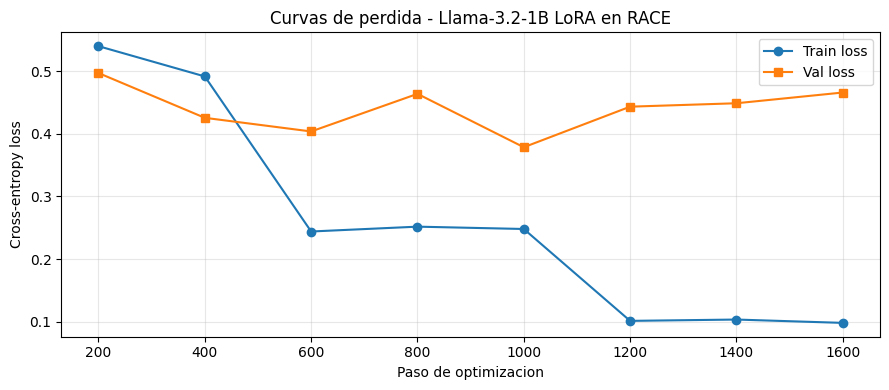

Grafica guardada como training_curves.png


In [19]:
import matplotlib.pyplot as plt

if len(history["step"]) > 0:
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(history["step"], history["train_loss"], label="Train loss", marker="o")
    ax.plot(history["step"], history["val_loss"],   label="Val loss",   marker="s")
    ax.set_xlabel("Paso de optimizacion")
    ax.set_ylabel("Cross-entropy loss")
    ax.set_title("Curvas de perdida - Llama-3.2-1B LoRA en RACE")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig("training_curves.png", dpi=150)
    plt.show()
    print("Grafica guardada como training_curves.png")
else:
    print("No se acumularon suficientes puntos para graficar.")


## 15. (Opcional) Recargar el modelo desde checkpoint


In [20]:
# Opcion A: desde adaptadores LoRA
def load_finetuned_model(base_model_name, lora_adapter_path, device):
    base = AutoModelForCausalLM.from_pretrained(
        base_model_name,
        torch_dtype=torch.float16 if device == "cuda" else torch.float32,
    )
    m = PeftModel.from_pretrained(base, lora_adapter_path)
    m = m.to(device)
    m.eval()
    return m

# Opcion B: desde state_dict completo
def load_from_state_dict(base_model_name, lora_cfg, checkpoint_path, device):
    base = AutoModelForCausalLM.from_pretrained(
        base_model_name,
        torch_dtype=torch.float16 if device == "cuda" else torch.float32,
    )
    m = get_peft_model(base, lora_cfg)
    m.load_state_dict(torch.load(checkpoint_path, map_location=device))
    m = m.to(device)
    m.eval()
    return m

print("Funciones de recarga definidas")
print("Uso: load_finetuned_model(MODEL_NAME, './llama_race_lora_adapter', DEVICE)")


Funciones de recarga definidas
Uso: load_finetuned_model(MODEL_NAME, './llama_race_lora_adapter', DEVICE)


## 16. Analisis cualitativo: ejemplos del test set


In [21]:
@torch.no_grad()
def analyze_examples(model, dataset_hf, tokenizer, device, n=10):
    model.eval()
    letters = ["A", "B", "C", "D"]

    for ex in list(dataset_hf.select(range(n))):
        ctx_text = build_context(ex["article"], ex["question"], ex["options"])
        scores   = []
        for letter in letters:
            full = ctx_text + f" {letter}"
            enc = tokenizer(full, return_tensors="pt",
                            max_length=MAX_SEQ_LEN, truncation=True).to(device)
            ctx_len = tokenizer(ctx_text, return_tensors="pt",
                                max_length=MAX_SEQ_LEN, truncation=True,
                                add_special_tokens=False)["input_ids"].shape[1]
            lp_all = torch.nn.functional.log_softmax(model(**enc).logits, dim=-1)
            tlen   = enc["input_ids"].shape[1]
            lp = sum(lp_all[0, p-1, enc["input_ids"][0,p].item()].item()
                     for p in range(ctx_len, tlen)) / max(tlen - ctx_len, 1)
            scores.append(lp)

        pred  = letters[int(np.argmax(scores))]
        check = "OK" if pred == ex["answer"] else "FAIL"
        print(f"[{check}] True={ex['answer']} Pred={pred} | Q: {ex['question'][:70]}")


analyze_examples(model, test_ds, tokenizer, DEVICE, n=10)


[OK] True=D Pred=D | Q: According to the passage we can see that_.
[OK] True=C Pred=C | Q: Ramps can help people_.
[OK] True=D Pred=D | Q: The word "Braille" means_.
[FAIL] True=C Pred=D | Q: What do you think the disabled would feel about the new law?
[OK] True=B Pred=B | Q: The fact that the new law has been passed shows that  _  .
[OK] True=A Pred=A | Q: .  . The driver of the bus is   _  .
[OK] True=D Pred=D | Q: .  The bus school will   _  .
[OK] True=C Pred=C | Q: .  . When the school bus comes, the farmers  are    _  .
[FAIL] True=D Pred=A | Q: .  . Which one of the following is true?
[FAIL] True=D Pred=B | Q: How many people does Mr. Brown see in the street one day? He sees   _ 
